In [1]:
import os
import importlib
import sys

# for math operations
import numpy as np
import scipy

# for plotting
from IPython.display import HTML
import matplotlib.pyplot as plt
import matplotlib.animation as anim
import matplotlib.pyplot as plt
import plotly.graph_objects as go

# for accelerated computing
import jax
import jax.numpy as jnp
import torch

# Python reachability toolbox
import hj_reachability as hj

# QP tools
import osqp
from scipy import sparse

In [113]:
import dubins_model
importlib.reload(dubins_model)
from dubins_model import Dubins3D

dubins = Dubins3D()

100%|##########|  2.8000/2.799999952316284 [00:00<00:00, 12.33sim_s/s]


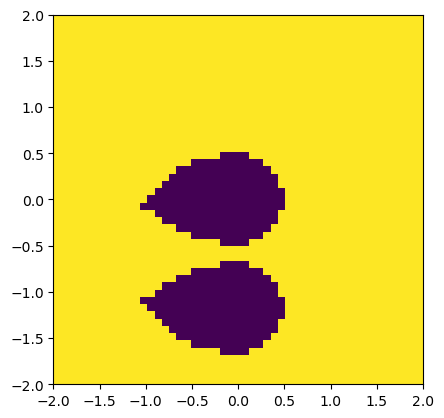

In [267]:
sys.path.append('./value_functions')
import hj_value_function
importlib.reload(hj_value_function)
from hj_value_function import HJValueFunction

value_func = HJValueFunction(dubins)

# Define failure set
x_c, y_c, radius = 0.0, -1.2, 0.5
obstacle1 = jnp.linalg.norm(np.array([0.0, 0.0]) - value_func.grid.states[..., :2], axis=-1) - radius
obstacle2 = jnp.linalg.norm(np.array([x_c, y_c]) - value_func.grid.states[..., :2] , axis=-1) - radius
failure_lx = jnp.minimum(obstacle1, obstacle2)

value_func.compute_V(failure_lx)

plt.imshow(value_func.val_grid[:, :, 0].T>0, origin='lower', extent=[-2, 2, -2, 2])

In [438]:
import safety_policies
importlib.reload(safety_policies)
from safety_policies import safety_filter, qp_filter, sampling_filter

In [269]:
# Set initial condition and goal state
x_ic = torch.tensor([-1.5, -0.5, np.pi/16])
x_goal = torch.tensor([1.5, -1.0, 0])
eps = 0.1

In [271]:
# Simulate over a bunch of initial conditions
num_trials = 100
N = 50
dt = 0.1

torch.manual_seed(0)

states = torch.zeros(num_trials, N, 3)
actions = torch.zeros(num_trials, N, 1)
values = torch.zeros(num_trials, N, 1)
sample_range = torch.tensor([0.1, 0.9, np.pi/4])
for i in range(num_trials):
    states[i, 0, :] = x_ic + torch.rand_like(x_ic)*sample_range*2 - sample_range
    for k in range(0, N-1):
        # Nominal policy, steer towards goal
        values[i, k, 0] = value_func.V(states[i, k, :])
        err = dubins.state_error(x_goal, states[i, k, :])
        if np.linalg.norm(err[:2]) < 0.15: # End trial when we reach the goal
            actions[i, k:, 0] = 0
            states[i, k+1:, :] = states[i, k, :]
            values[i, k+1:, :] = values[i, k, :]

            break
        else:
            theta = np.arctan2(err[1], err[0])
            theta_err = 2*dubins.state_error(torch.tensor([0, 0, theta]), states[i, k, :])[2]
            actions[i, k, 0] = max(-u_max, min(u_max, theta_err))

        # Filter the policy
        actions[i, k, 0] = safety_filter(actions[i, k, 0], value_func.V, vgrad, states[i, k, :], u_max, eps)
        
        states[i, k +1:k+2, :] = dubins.discrete_dynamics(states[i, k:k+1, :], actions[i, k:k+1, :], dt)

# result_tensor = min_tensor + torch.rand_like(min_tensor) * (max_tensor - min_tensor)

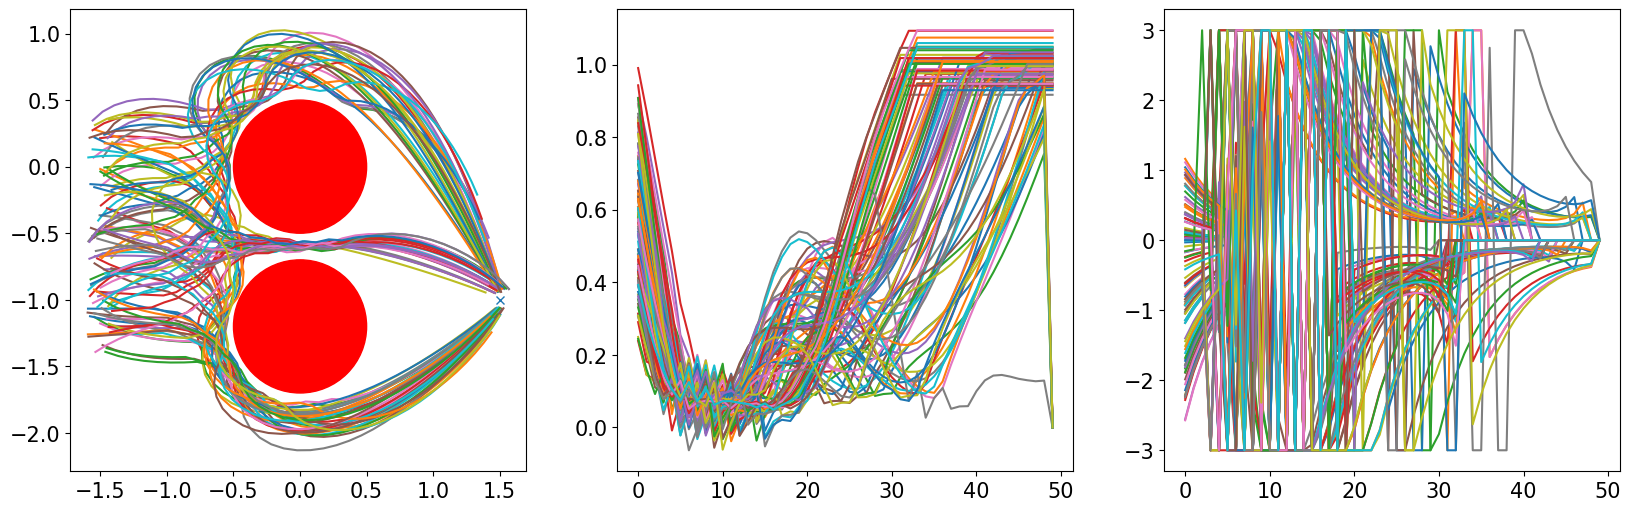

In [454]:
plt.rc('font', size=15) 
fig = plt.figure(figsize=(20, 6))
ax = plt.subplot(1, 3, 1)
# img = ax.imshow(value_func.val_grid[:, :, 0].T>eps, origin='lower', extent=[-2, 2, -2, 2])
circ1 = patches.Circle((x_c, y_c), radius=radius, facecolor='red', edgecolor='red')
ax.add_patch(circ1)
circ1 = patches.Circle((0, 0), radius=radius, facecolor='red', edgecolor='red')
ax.add_patch(circ1)
ax.plot(x_goal[0], x_goal[1], marker='x')
obstacle1 = jnp.linalg.norm(np.array([0.0, 0.0]) - value_func.grid.states[..., :2], axis=-1) - radius
obstacle2 = jnp.linalg.norm(np.array([x_c, y_c]) - value_func.grid.states[..., :2] , axis=-1) - radius


for i in range(num_trials):
    plt.plot(states[i, :, 0], states[i, :, 1])
plt.axis('equal')
plt.subplot(1, 3, 2)
plt.plot(values.squeeze().T)
plt.subplot(1, 3, 3)
plt.plot(actions.squeeze().T);

In [434]:
# Simulate over a bunch of initial conditions with QP
num_trials = 100
N = 50
dt = 0.1

torch.manual_seed(0)

qp_states = torch.zeros(num_trials, N, 3)
qp_actions = torch.zeros(num_trials, N, 1)
qp_values = torch.zeros(num_trials, N, 1)
sample_range = torch.tensor([0.1, 0.9, np.pi/4])
for i in range(num_trials):
    qp_states[i, 0, :] = states[i, 0, :]
    for k in range(0, N-1):
        # Nominal policy, steer towards goal
        qp_values[i, k, 0] = value_func.V(qp_states[i, k, :])
        err = dubins.state_error(x_goal, qp_states[i, k, :])
        if np.linalg.norm(err[:2]) < 0.15: # End trial when we reach the goal
            qp_actions[i, k:, 0] = 0
            qp_states[i, k+1:, :] = qp_states[i, k, :]
            qp_values[i, k+1:, :] = qp_values[i, k, :]

            break
        else:
            theta = np.arctan2(err[1], err[0])
            theta_err = 2*dubins.state_error(torch.tensor([0, 0, theta]), qp_states[i, k, :])[2]
            qp_actions[i, k, 0] = max(-u_max, min(u_max, theta_err))

        # Solve QP
        out, status = qp_filter(qp_actions[i, k, 0], value_func.V, vgrad, qp_states[i, k:k+1,:], u_max, eps, dubins, dt)
        if status != 'solved': # Fall back to safety filter if QP fails
            qp_actions[i, k, 0] = safety_filter(qp_actions[i, k, 0], value_func.V, vgrad, qp_states[i, k, :], u_max, eps)
        else:
            qp_actions[i, k, 0] = out
            next_state = dubins.discrete_dynamics(qp_states[i, k:k+1, :], qp_actions[i, k:k+1, :], dt)
            if value_func.V(next_state.squeeze()) < eps:
                qp_actions[i, k, 0] = safety_filter(qp_actions[i, k, 0], value_func.V, vgrad, qp_states[i, k, :], u_max, eps)

        # Filter the policy
        # qp_actions[i, k, 0] = safety_filter(qp_actions[i, k, 0], value_func.V, vgrad, qp_states[i, k, :], u_max, eps)
        
        qp_states[i, k +1:k+2, :] = dubins.discrete_dynamics(qp_states[i, k:k+1, :], qp_actions[i, k:k+1, :], dt)


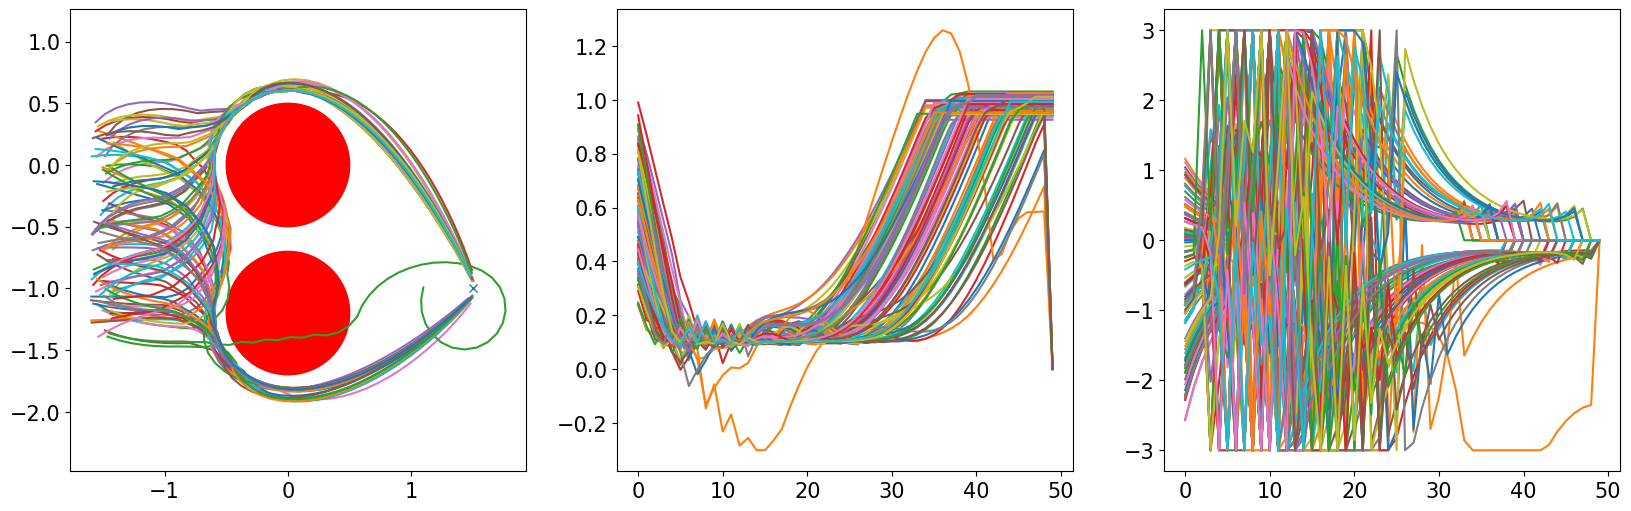

In [455]:
fig = plt.figure(figsize=(20, 6))
ax = plt.subplot(1, 3, 1)
# img = ax.imshow(value_func.val_grid[:, :, 0].T>eps, origin='lower', extent=[-2, 2, -2, 2])
circ1 = patches.Circle((x_c, y_c), radius=radius, facecolor='red', edgecolor='red')
ax.add_patch(circ1)
circ1 = patches.Circle((0, 0), radius=radius, facecolor='red', edgecolor='red')
ax.add_patch(circ1)
ax.plot(x_goal[0], x_goal[1], marker='x')
obstacle1 = jnp.linalg.norm(np.array([0.0, 0.0]) - value_func.grid.states[..., :2], axis=-1) - radius
obstacle2 = jnp.linalg.norm(np.array([x_c, y_c]) - value_func.grid.states[..., :2] , axis=-1) - radius


for i in range(num_trials):
    plt.plot(qp_states[i, :, 0], qp_states[i, :, 1])
plt.axis('equal')
plt.subplot(1, 3, 2)
plt.plot(qp_values.squeeze().T)
plt.subplot(1, 3, 3)
plt.plot(qp_actions.squeeze().T);

In [447]:
torch.argmin(qp_values)

tensor([[[0.6001],
         [0.4835],
         [0.3690],
         ...,
         [0.9531],
         [0.9531],
         [0.9531]],

        [[0.5901],
         [0.4270],
         [0.2753],
         ...,
         [1.0116],
         [1.0116],
         [1.0116]],

        [[0.5905],
         [0.4506],
         [0.2775],
         ...,
         [0.8996],
         [0.9773],
         [0.9773]],

        ...,

        [[0.4042],
         [0.2581],
         [0.1286],
         ...,
         [1.0115],
         [1.0115],
         [1.0115]],

        [[0.8086],
         [0.6220],
         [0.4426],
         ...,
         [1.0117],
         [1.0117],
         [1.0117]],

        [[0.3926],
         [0.2948],
         [0.2165],
         ...,
         [0.9938],
         [0.9938],
         [0.9938]]])

In [445]:
# Simulate over a bunch of initial conditions with QP
num_trials = 100
num_samples = 20
N = 50
dt = 0.1

torch.manual_seed(0)

samp_states = torch.zeros(num_trials, N, 3)
samp_actions = torch.zeros(num_trials, N, 1)
samp_values = torch.zeros(num_trials, N, 1)
sample_range = torch.tensor([0.1, 0.9, np.pi/4])
for i in range(num_trials):
    samp_states[i, 0, :] = x_ic + torch.rand_like(x_ic)*sample_range*2 - sample_range
    for k in range(0, N-1):
        # Nominal policy, steer towards goal
        samp_values[i, k, 0] = value_func.V(samp_states[i, k, :])
        err = dubins.state_error(x_goal, samp_states[i, k, :])
        if np.linalg.norm(err[:2]) < 0.15: # End trial when we reach the goal
            samp_actions[i, k:, 0] = 0
            samp_states[i, k+1:, :] = samp_states[i, k, :]
            samp_values[i, k+1:, :] = samp_values[i, k, :]

            break
        else:
            theta = np.arctan2(err[1], err[0])
            theta_err = 2*dubins.state_error(torch.tensor([0, 0, theta]), samp_states[i, k, :])[2]
            samp_actions[i, k, 0] = max(-u_max, min(u_max, theta_err))

        out = sampling_filter(samp_actions[i, k, 0], value_func.V, vgrad, samp_states[i, k, :], u_max, eps, dubins, dt, num_samples)
        # switching_action = safety_filter(samp_actions[i, k, 0], value_func.V, vgrad, samp_states[i, k, :], u_max, eps)

        # sample_actions = torch.linspace(-u_max, u_max, num_samples).unsqueeze(1)
        # sample_actions = torch.vstack((sample_actions, samp_actions[i, k:k+1, :]))
        # next_states = dubins.discrete_dynamics(samp_states[i, k, :].repeat(num_samples+1, 1), sample_actions, dt)
        # possible_values = torch.tensor([value_func.V(next_states[j, :]) for j in range(num_samples+1)])
        # sample_actions = sample_actions[possible_values > eps]

        if out is None:
            samp_actions[i, k, 0] = safety_filter(samp_actions[i, k, 0], value_func.V, vgrad, samp_states[i, k, :], u_max, eps)
        else:
            sampling_action, value = out
            if value < eps:
                samp_actions[i, k, 0] = safety_filter(samp_actions[i, k, 0], value_func.V, vgrad, samp_states[i, k, :], u_max, eps)
            else:
                samp_actions[i, k, 0] = sampling_action
            # samp_actions[i, k, 0] = out
            # next_state = dubins.discrete_dynamics(qp_states[i, k:k+1, :], qp_actions[i, k:k+1, :], dt)
            # if value_func.V(next_state.squeeze()) < eps:
            #     qp_actions[i, k, 0] = safety_filter(qp_actions[i, k, 0], value_func.V, vgrad, qp_states[i, k, :], u_max, eps)
            

        # if len(sample_actions) > 0:
        #     # print(possible_values)
        #     # print(torch.abs(sample_actions - samp_actions[i, k, 0]))
        #     # print(torch.argmin(torch.abs(sample_actions - samp_actions[i, k, 0])))
        #     samp_actions[i, k, 0] = sample_actions[torch.abs(torch.argmin(sample_actions - samp_actions[i, k, 0]))]
        # else:
        #     samp_actions[i, k, 0] = switching_action
        
        samp_states[i, k +1:k+2, :] = dubins.discrete_dynamics(samp_states[i, k:k+1, :], samp_actions[i, k:k+1, :], dt)

# result_tensor = min_tensor + torch.rand_like(min_tensor) * (max_tensor - min_tensor)

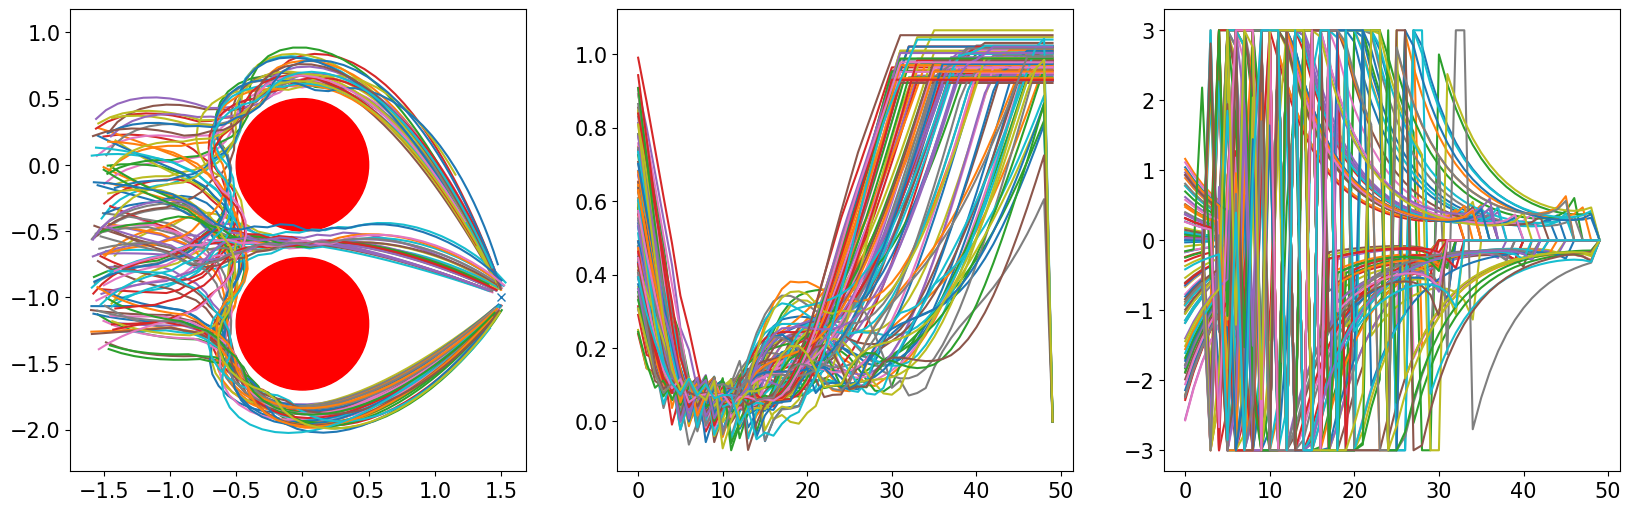

In [456]:
fig = plt.figure(figsize=(20, 6))
ax = plt.subplot(1, 3, 1)
# img = ax.imshow(value_func.val_grid[:, :, 0].T>eps, origin='lower', extent=[-2, 2, -2, 2])
circ1 = patches.Circle((x_c, y_c), radius=radius, facecolor='red', edgecolor='red')
ax.add_patch(circ1)
circ1 = patches.Circle((0, 0), radius=radius, facecolor='red', edgecolor='red')
ax.add_patch(circ1)
ax.plot(x_goal[0], x_goal[1], marker='x')
obstacle1 = jnp.linalg.norm(np.array([0.0, 0.0]) - value_func.grid.states[..., :2], axis=-1) - radius
obstacle2 = jnp.linalg.norm(np.array([x_c, y_c]) - value_func.grid.states[..., :2] , axis=-1) - radius


for i in range(num_trials):
    plt.plot(samp_states[i, :, 0], samp_states[i, :, 1])
plt.axis('equal')
plt.subplot(1, 3, 2)
plt.plot(samp_values.squeeze().T)
plt.subplot(1, 3, 3)
plt.plot(samp_actions.squeeze().T);

Text(0, 0.5, 'Prevalence')

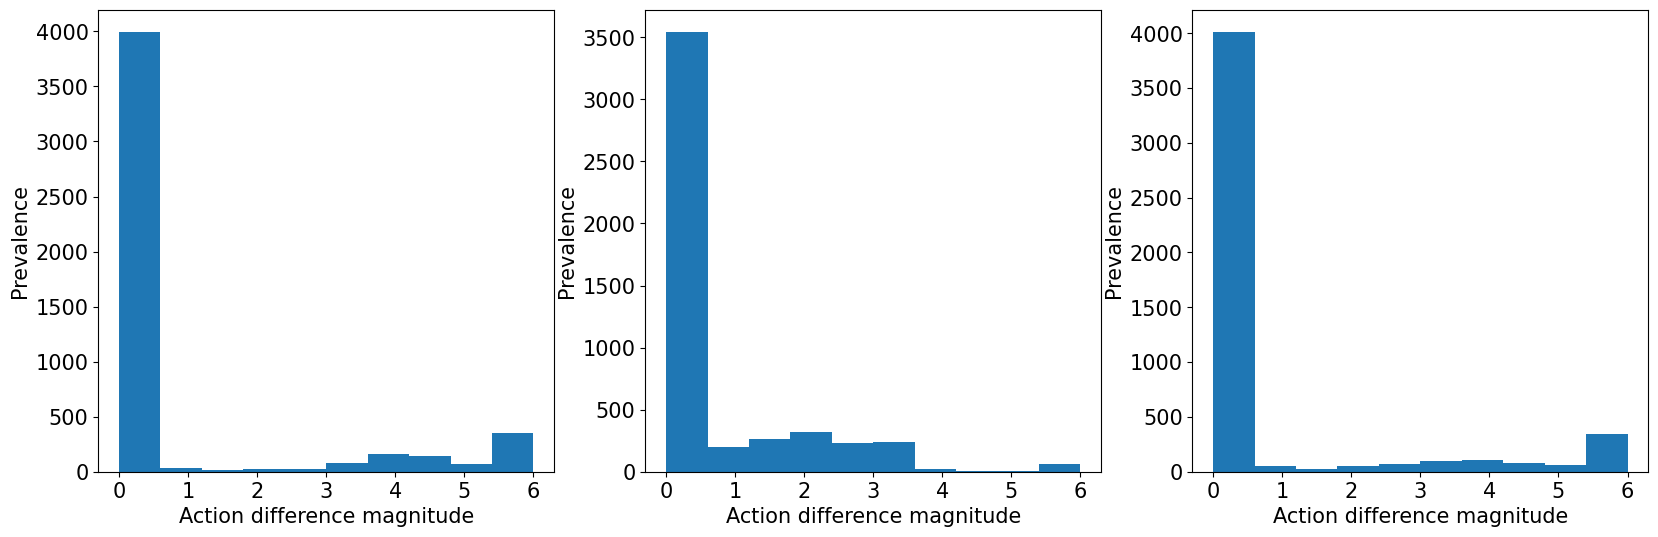

In [461]:
plt.figure(figsize=(20,6))
plt.subplot(1, 3, 1)
plt.hist(torch.abs(torch.diff(actions.squeeze()).flatten()))
plt.xlabel("Action difference magnitude")
plt.ylabel("Prevalence")
plt.subplot(1, 3, 2)
plt.hist(torch.abs(torch.diff(qp_actions.squeeze()).flatten()))
plt.xlabel("Action difference magnitude")
plt.ylabel("Prevalence")
plt.subplot(1, 3, 3)
plt.hist(torch.abs(torch.diff(samp_actions.squeeze()).flatten()))
plt.xlabel("Action difference magnitude")
plt.ylabel("Prevalence")

In [110]:
# Simulate with safety filter
import safety_policies
importlib.reload(safety_policies)
from safety_policies import safety_filter
import v_func_utils
importlib.reload(v_func_utils)
from v_func_utils import get_spatial_grad, compute_jacobian

N = 100
dt = 0.1
actions = torch.zeros(N, 1)
values = torch.zeros(N, 1)
states = torch.zeros(N, 3)
states[0,:] = x_ic
u_max = dubins.max_turn_rate

# Define function for gradient
vgrad = lambda state: get_spatial_grad(value_func.V, state)
values = []
speed = dubins.speed
for k in range(0, N-1):
    # Nominal policy, steer towards goal
    err = dubins.state_error(x_goal, states[k, :])
    if np.linalg.norm(err[:2]) < 0.1:
        dubins.speed = 0 # Stop when we reach the goal
        actions[k, 0] = 0
    else:
        theta = np.arctan2(err[1], err[0])
        theta_err = 0.1*dubins.state_error(torch.tensor([0, 0, theta]), states[k, :])[2]
        actions[k, 0] = max(-u_max, min(u_max, theta_err))

    # Filter the policy
    actions[k, 0] = safety_filter(actions[k, 0], value_func.V, vgrad, states[k, :], u_max, eps)

    values.append(value_func.V(states[k, :]))
    
    states[k +1:k+2, :] = dubins.discrete_dynamics(states[k:k+1, :], actions[k:k+1, :], dt)
dubins.speed = speed


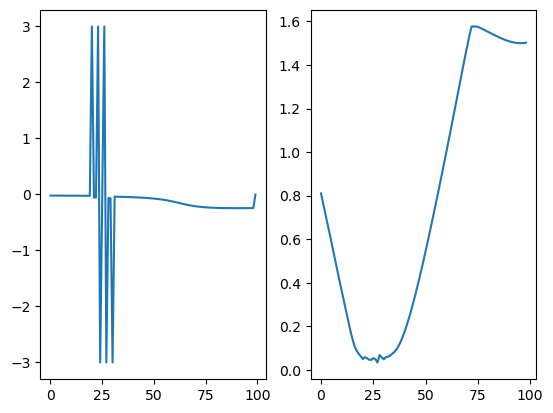

In [111]:
plt.subplot(1, 2, 1)
plt.plot(actions)
plt.subplot(1, 2, 2)
plt.plot(values)

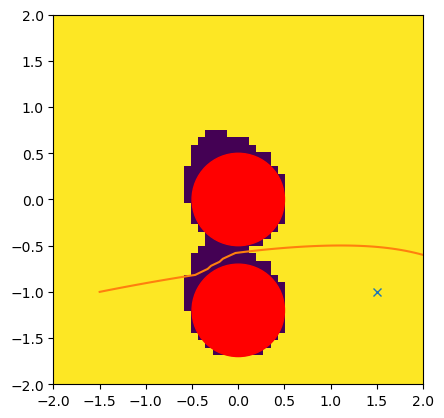

In [112]:
# Animate
import matplotlib.animation as animation
import matplotlib.patches as patches

fig, ax = plt.subplots()
img = ax.imshow(value_func.val_grid[:, :, 0].T>eps, origin='lower', extent=[-2, 2, -2, 2])
circ1 = patches.Circle((x_c, y_c), radius=radius, facecolor='red', edgecolor='red')
ax.add_patch(circ1)
circ1 = patches.Circle((0, 0), radius=radius, facecolor='red', edgecolor='red')
ax.add_patch(circ1)
ax.plot(x_goal[0], x_goal[1], marker='x')
obstacle1 = jnp.linalg.norm(np.array([0.0, 0.0]) - value_func.grid.states[..., :2], axis=-1) - radius
obstacle2 = jnp.linalg.norm(np.array([x_c, y_c]) - value_func.grid.states[..., :2] , axis=-1) - radius
line, = ax.plot([], [])

def animate(k):
    theta_idx = value_func.theta_to_grid(states[k, 2] % (2*np.pi))
    img.set_array(value_func.val_grid[:, :, theta_idx].T>eps) #update the image data.
    line.set_data(states[:k, 0], states[:k, 1])
    return img, line,

ani = animation.FuncAnimation(fig, animate, frames=states.shape[0], interval=200, blit=True) #adjust interval

ani.save('reachability_animation.gif')  # Save as GIF

In [61]:
# Simulate with QP
import safety_policies
importlib.reload(safety_policies)
from safety_policies import safety_filter, qp_filter

N = 100
dt = 0.1
actions = torch.zeros(N, 1)
values = torch.zeros(N, 1)
states = torch.zeros(N, 3)
states[0,:] = torch.tensor([-1.5, -1.5, -0.05])
u_max = 3

# Define function for gradient
vgrad = lambda state: get_spatial_grad(value_func.V, state, eps=0.05)

eps = 0.05
dubins.speed = 0.5
goal_state = torch.tensor([1.5, 1.5, 0])
for k in range(0, N-1):
    # Nominal policy, steer towards goal
    err = dubins.state_error(goal_state, states[k, :])
    if np.linalg.norm(err[:2]) < 0.1:
        dubins.speed = 0 # Stop when we reach the goal
        actions[k, 0] = 0
    else:
        theta = np.arctan2(err[1], err[0])
        theta_err = dubins.state_error(torch.tensor([0, 0, theta]), states[k, :])[2]
        actions[k, 0] = max(-u_max, min(u_max, theta_err))

    # Filter the policy using a QP
    actions[k, 0], status = qp_filter(actions[k, 0], value_func.V, vgrad, states[k:k+1,:], u_max, 0.03, dubins, dt)

    if status != 'solved': # Fall back to safety filter
        print("infeasible", k)
        actions[k, 0] = safety_filter(actions[k, 0], value_func.V, vgrad, states[k, :], u_max, eps)
    
    # actions[k, 0] = safety_filter(actions[k, 0], value_func.V, vgrad, states[k, :], u_max, eps)
    
    states[k +1:k+2, :] = dubins.discrete_rk4(states[k:k+1, :], actions[k:k+1, :], dt)

plt.figure(figsize=(15,5))
plt.subplot(1, 2, 1)
plt.plot(states[:, 0], states[:, 1])
plt.subplot(1, 2, 2)
plt.plot(actions)
plt.ylim(-2, 3)

AttributeError: 'Dubins3D' object has no attribute 'discrete_rk4'

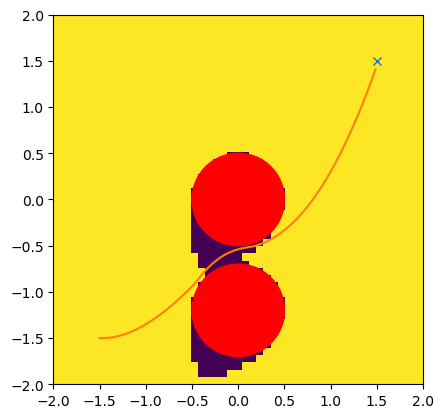

In [ ]:
# Animate
import matplotlib.animation as animation
import matplotlib.patches as patches

fig, ax = plt.subplots()
img = ax.imshow(value_func.val_grid[:, :, 0].T>0, origin='lower', extent=[-2, 2, -2, 2])
circ1 = patches.Circle((x_c, y_c), radius=radius, facecolor='red', edgecolor='red')
ax.add_patch(circ1)
circ1 = patches.Circle((0, 0), radius=radius, facecolor='red', edgecolor='red')
ax.add_patch(circ1)
ax.plot(goal_state[0], goal_state[1], marker='x')
# obstacle1 = jnp.linalg.norm(np.array([0.0, 0.0]) - value_func.grid.states[..., :2], axis=-1) - radius
# obstacle2 = jnp.linalg.norm(np.array([x_c, y_c]) - value_func.grid.states[..., :2] , axis=-1) - radius
line, = ax.plot([], [])

def animate(k):
    theta_idx = value_func.theta_to_grid(states[k, 2] % (2*np.pi))
    img.set_array(value_func.val_grid[:, :, theta_idx].T>0) #update the image data.
    line.set_data(states[:k, 0], states[:k, 1])
    return img, line,

ani = animation.FuncAnimation(fig, animate, frames=states.shape[0], interval=200, blit=True) #adjust interval

ani.save('reachability_animation.gif')  # Save as GIF

(-2.0, 3.0)

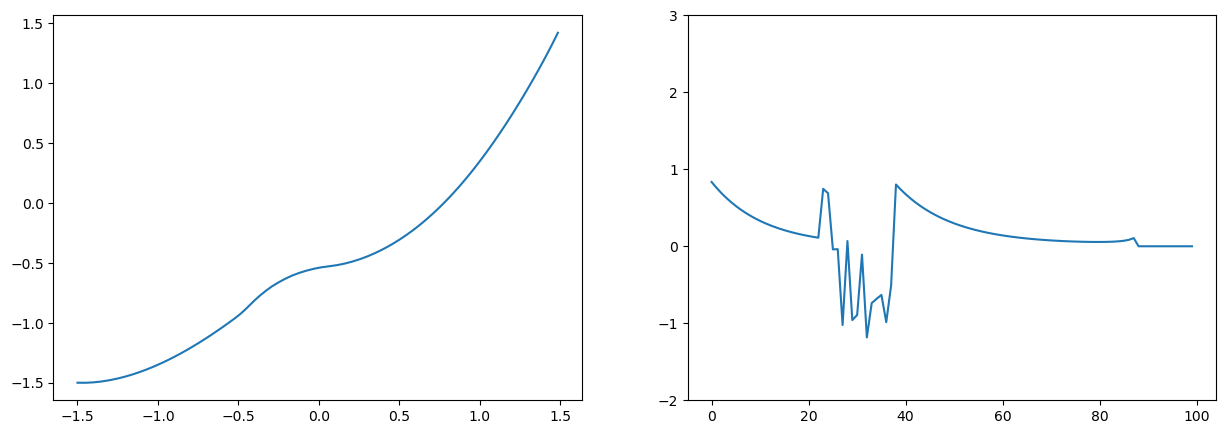

In [742]:
# Simulate with sampling
import safety_policies
importlib.reload(safety_policies)
from safety_policies import safety_filter, qp_filter, sampling_filter

N = 100
dt = 0.1
actions = torch.zeros(N, 1)
values = torch.zeros(N, 1)
states = torch.zeros(N, 3)
states[0,:] = torch.tensor([-1.5, -1.5, -0.05])
u_max = 3

# Define function for gradient
vgrad = lambda state: get_spatial_grad(value_func.V, state, eps=0.05)

eps = 0.06
dubins.speed = 0.5
goal_state = torch.tensor([1.5, 1.5, 0])
num_samples = 10
for k in range(0, N-1):
    # Nominal policy, steer towards goal
    err = dubins.state_error(goal_state, states[k, :])
    if np.linalg.norm(err[:2]) < 0.1:
        dubins.speed = 0 # Stop when we reach the goal
        actions[k, 0] = 0
    else:
        theta = np.arctan2(err[1], err[0])
        theta_err = dubins.state_error(torch.tensor([0, 0, theta]), states[k, :])[2]
        actions[k, 0] = max(-u_max, min(u_max, theta_err))

    # Filter the policy using sampling
    actions[k, 0] = sampling_filter(actions[k, 0], value_func.V, vgrad, states[k, :], u_max, eps, dubins, dt, num_samples)
    
    states[k +1:k+2, :] = dubins.discrete_rk4(states[k:k+1, :], actions[k:k+1, :], dt)

plt.figure(figsize=(15,5))
plt.subplot(1, 2, 1)
plt.plot(states[:, 0], states[:, 1])
plt.subplot(1, 2, 2)
plt.plot(actions)
plt.ylim(-2, 3)

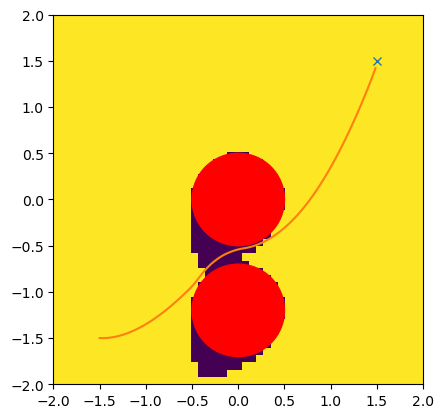

In [743]:
import matplotlib.animation as animation
import matplotlib.patches as patches

fig, ax = plt.subplots()
img = ax.imshow(value_func.val_grid[:, :, 0].T>0, origin='lower', extent=[-2, 2, -2, 2])
circ1 = patches.Circle((x_c, y_c), radius=radius, facecolor='red', edgecolor='red')
ax.add_patch(circ1)
circ1 = patches.Circle((0, 0), radius=radius, facecolor='red', edgecolor='red')
ax.add_patch(circ1)
ax.plot(goal_state[0], goal_state[1], marker='x')
# obstacle1 = jnp.linalg.norm(np.array([0.0, 0.0]) - value_func.grid.states[..., :2], axis=-1) - radius
# obstacle2 = jnp.linalg.norm(np.array([x_c, y_c]) - value_func.grid.states[..., :2] , axis=-1) - radius
line, = ax.plot([], [])

def animate(k):
    theta_idx = value_func.theta_to_grid(states[k, 2] % (2*np.pi))
    img.set_array(value_func.val_grid[:, :, theta_idx].T>0) #update the image data.
    line.set_data(states[:k, 0], states[:k, 1])
    return img, line,

ani = animation.FuncAnimation(fig, animate, frames=states.shape[0], interval=200, blit=True) #adjust interval

ani.save('reachability_animation.gif')  # Save as GIF